# Step 5b: K-Means Clustering — Data-Driven Climate Groups
### DI 501 Term Project | Eda Yilmaz

**Goal:**  
Apply k-means clustering on country-level mean climate features across **all 38 countries** in the global CY-Bench maize dataset to derive data-driven groupings. These clusters replace the theoretical Köppen-based panels as the grouping variable for all downstream analysis (RQ1 and RQ2).

**Input:** `master_global_ml_dataset.csv` (hemisphere-adjusted features from step_global_pipeline)  
**Features used for clustering:** `heat_stress_days`, `prec_gs` (country-level means)  
**Unit of clustering:** One point per country (38 countries)  
**Output:** Cluster labels added to `cv_global_per_region.csv` and `master_global_ml_dataset.csv`

---

## 1. Load Data & Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy import stats

plt.rcParams['figure.dpi'] = 120

CLUSTER_COLORS = {0: '#e07b39', 1: '#3b82c4', 2: '#5aad5a'}

# Load global ML dataset (hemisphere-adjusted features, 2001+)
ml_df = pd.read_csv('./master_global_ml_dataset.csv')

print(f'Global ML dataset: {len(ml_df):,} observations')
print(f'Countries: {ml_df["country"].nunique()}')
print(f'Regions:   {ml_df["adm_id"].nunique():,}')
print(f'Years:     {ml_df["harvest_year"].min()}–{ml_df["harvest_year"].max()}')
print()
print('Observations per country:')
print(ml_df.groupby('country').size().sort_values(ascending=False).to_string())

Global ML dataset: 157,894 observations
Countries: 38
Regions:   8,768
Years:     2001–2023

Observations per country:
country
BR    89878
US    37738
IN     7302
AR     6095
DE     3859
IT     1889
FR     1812
ZM     1058
ES      949
ET      869
RO      815
CN      672
BF      592
EL      466
ML      403
HU      391
SN      391
PL      301
TD      240
NE      220
CZ      212
AO      198
ZA      185
AT      180
LT      155
MZ      141
PT      138
NL      126
BG      120
MG      115
SK       94
LS       89
BE       85
MX       52
HR       32
DK       12
MW       10
SE       10


---
## 2. Compute Country-Level Mean Climate Features

Clustering is done at the **country level** — one representative point per country.  
We use the already-computed, hemisphere-adjusted features from the global pipeline.

In [2]:
# Compute country-level means directly from the global ML dataset
country_df = (
    ml_df.groupby('country')[['heat_stress_days', 'prec_gs']]
    .mean()
    .reset_index()
    .round(2)
)

print(f'Country-level means computed for {len(country_df)} countries:')
print()
print(country_df.sort_values('heat_stress_days', ascending=False).to_string(index=False))

Country-level means computed for 38 countries:

country  heat_stress_days  prec_gs
     NE             85.99   265.88
     SN             74.80   570.12
     TD             71.56   632.51
     BF             70.53   557.18
     ML             63.37   728.53
     MZ             43.73   785.38
     AR             40.30   668.62
     US             38.43   566.77
     ES             38.35   242.82
     EL             37.76   249.73
     MG             35.23  1160.74
     CN             35.07   765.54
     BR             32.34   984.14
     MX             30.62   683.33
     IT             29.71   460.29
     BG             27.62   369.39
     ZA             24.46   547.15
     HU             19.29   406.93
     RO             19.26   426.42
     AO             18.13   946.48
     PT             16.66   221.37
     HR             16.50   519.06
     IN             15.32   179.56
     ET             14.84   285.51
     SK             11.46   473.63
     FR             10.51   413.80
     MW

---
## 2b. Pre-Clustering Data Distribution Check

Before applying k-means it is important to inspect the distribution of the clustering features:
- **Shape:** Are the features normally distributed, or skewed? K-means assumes roughly spherical clusters; heavy skew can distort distances.
- **Outliers:** Extreme values pull cluster centres away from the bulk of the data.
- **Scale:** Features on very different scales will dominate the distance calculation — this is why we standardise with `StandardScaler` before fitting.

We check histograms, KDE, and a scatter plot of the raw (unstandardised) values.

In [ ]:
from scipy import stats as scipy_stats

features = ['heat_stress_days', 'prec_gs']
labels   = ['Heat Stress Days (growing season)', 'Growing Season Precipitation (mm)']

# ── Summary statistics ────────────────────────────────────────────────────────
print('=== Descriptive Statistics — Clustering Features (country-level means) ===')
print()
for feat, lbl in zip(features, labels):
    vals = country_df[feat].values
    skew = scipy_stats.skew(vals)
    kurt = scipy_stats.kurtosis(vals)
    stat, p_norm = scipy_stats.shapiro(vals)   # Shapiro-Wilk normality test
    print(f'{lbl}')
    print(f'  n={len(vals)}  mean={vals.mean():.1f}  std={vals.std():.1f}  '
          f'min={vals.min():.1f}  max={vals.max():.1f}')
    print(f'  Skewness={skew:.2f}  Kurtosis={kurt:.2f}')
    print(f'  Shapiro-Wilk: W={stat:.3f}, p={p_norm:.4f} '
          f'→ {"NOT normal (p<0.05)" if p_norm < 0.05 else "approx. normal"}')
    print()

# ── Figure: histograms + KDE + raw scatter ────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.35)

HIST_COLOR = '#3b82c4'
KDE_COLOR  = '#e07b39'

for row_idx, (feat, lbl) in enumerate(zip(features, labels)):
    vals = country_df[feat].values

    # Histogram + KDE
    ax_hist = fig.add_subplot(gs[row_idx, 0])
    ax_hist.hist(vals, bins=10, color=HIST_COLOR, alpha=0.65, edgecolor='white', linewidth=0.7)
    ax2 = ax_hist.twinx()
    kde_x = np.linspace(vals.min() - vals.std(), vals.max() + vals.std(), 200)
    kde   = scipy_stats.gaussian_kde(vals)
    ax2.plot(kde_x, kde(kde_x), color=KDE_COLOR, linewidth=2.2, label='KDE')
    ax2.set_ylabel('Density', fontsize=9, color=KDE_COLOR)
    ax2.tick_params(axis='y', labelcolor=KDE_COLOR, labelsize=8)
    ax_hist.set_xlabel(lbl, fontsize=10)
    ax_hist.set_ylabel('Count', fontsize=10)
    ax_hist.set_title(f'Distribution — {lbl}', fontsize=11)
    ax_hist.grid(alpha=0.25)

    # Box plot
    ax_box = fig.add_subplot(gs[row_idx, 1])
    bp = ax_box.boxplot(vals, vert=True, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2},
                        flierprops={'marker': 'o', 'markersize': 5,
                                    'markerfacecolor': '#e07b39', 'alpha': 0.7})
    bp['boxes'][0].set_facecolor(HIST_COLOR)
    bp['boxes'][0].set_alpha(0.6)

    # Annotate outlier country codes
    q1, q3  = np.percentile(vals, [25, 75])
    iqr      = q3 - q1
    out_mask = (vals < q1 - 1.5*iqr) | (vals > q3 + 1.5*iqr)
    for iso2, v in zip(country_df['country'].values, vals):
        if (v < q1 - 1.5*iqr) or (v > q3 + 1.5*iqr):
            ax_box.text(1.08, v, iso2, fontsize=8, va='center', color='#e07b39')

    ax_box.set_title(f'Box Plot — {lbl}', fontsize=11)
    ax_box.set_ylabel(lbl, fontsize=10)
    ax_box.set_xticks([])
    ax_box.grid(axis='y', alpha=0.25)

    # Q-Q plot
    ax_qq = fig.add_subplot(gs[row_idx, 2])
    (osm, osr), (slope, intercept, r) = scipy_stats.probplot(vals, dist='norm')
    ax_qq.scatter(osm, osr, color=HIST_COLOR, alpha=0.75, s=40, zorder=3)
    line_x = np.array([osm.min(), osm.max()])
    ax_qq.plot(line_x, slope * line_x + intercept,
               color=KDE_COLOR, linewidth=2, linestyle='--', label=f'R²={r**2:.3f}')
    ax_qq.set_xlabel('Theoretical Quantiles', fontsize=10)
    ax_qq.set_ylabel('Sample Quantiles', fontsize=10)
    ax_qq.set_title(f'Q-Q Plot — {lbl}', fontsize=11)
    ax_qq.legend(fontsize=9)
    ax_qq.grid(alpha=0.25)

fig.suptitle('Pre-Clustering Feature Distribution Check\n'
             '(country-level means, n=38 countries)',
             fontsize=13, y=1.01)
plt.savefig('./fig_preclustering_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_preclustering_distributions.png')

# ── Raw scatter (before clustering colours are applied) ───────────────────────
fig2, ax = plt.subplots(figsize=(9, 6))
ax.scatter(country_df['heat_stress_days'], country_df['prec_gs'],
           color='#3b82c4', s=80, alpha=0.75, edgecolors='white', linewidth=0.6, zorder=3)
for _, row in country_df.iterrows():
    ax.annotate(row['country'],
                (row['heat_stress_days'], row['prec_gs']),
                textcoords='offset points', xytext=(5, 4), fontsize=8, color='#333333')
ax.set_xlabel('Mean Heat Stress Days (growing season)', fontsize=12)
ax.set_ylabel('Mean Growing Season Precipitation (mm)', fontsize=12)
ax.set_title('Raw Feature Space — Before Clustering\n(n=38 countries, unstandardised)',
             fontsize=13)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('./fig_preclustering_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_preclustering_scatter.png')
print()
print('Key observations:')
print('  • Heat stress days: right-skewed (Sahel countries pull the tail)')
print('  • Precipitation: right-skewed (BR, MG, MW, ZM are high-rainfall outliers)')
print('  • The two features are on very different scales → StandardScaler is essential')
print('  • NE, SN, TD, BF, ML form a visible high-heat cluster already in raw space')

---
## 3. Choosing the Number of Clusters — Elbow & Silhouette

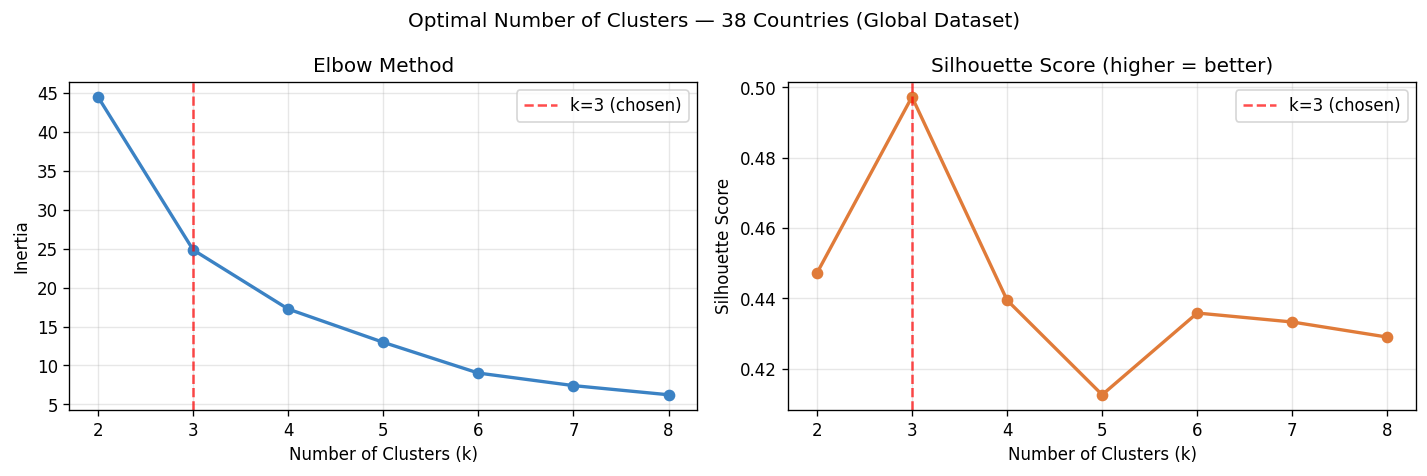

Saved: fig_elbow_silhouette_global.png

k=2: silhouette = 0.4471
k=3: silhouette = 0.4972 <-- chosen
k=4: silhouette = 0.4395
k=5: silhouette = 0.4126
k=6: silhouette = 0.4358
k=7: silhouette = 0.4333
k=8: silhouette = 0.4290


In [3]:
X = country_df[['heat_stress_days', 'prec_gs']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'o-', color='#3b82c4', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (chosen)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', color='#e07b39', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (chosen)')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Optimal Number of Clusters — 38 Countries (Global Dataset)', fontsize=12)
plt.tight_layout()
plt.savefig('./fig_elbow_silhouette_global.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_elbow_silhouette_global.png')
print()
for k, s in zip(k_range, silhouettes):
    marker = ' <-- chosen' if k == 3 else ''
    print(f'k={k}: silhouette = {s:.4f}{marker}')

---
## 4. Apply K-Means with k=3

We use k=3 to match the theoretical number of panels and enable direct comparison.

In [4]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
country_df['cluster'] = km3.fit_predict(X_scaled)

print('K-MEANS CLUSTERING RESULTS (k=3, 38 countries)')
print()
for c in sorted(country_df['cluster'].unique()):
    members = sorted(country_df[country_df['cluster'] == c]['country'].tolist())
    center  = scaler.inverse_transform(km3.cluster_centers_[c].reshape(1, -1))[0]
    n_regions = ml_df[ml_df['country'].isin(members)]['adm_id'].nunique()
    n_obs     = ml_df[ml_df['country'].isin(members)].shape[0]
    print(f'Cluster {c} — {len(members)} countries, {n_regions:,} regions, {n_obs:,} obs')
    print(f'  Countries:          {members}')
    print(f'  Center:             heat_stress_days={center[0]:.1f} days, prec_gs={center[1]:.0f} mm')
    print()

# Highlight Brazil and US specifically
print('─' * 50)
for focus in ['BR', 'US']:
    row = country_df[country_df['country'] == focus]
    if len(row):
        c = row['cluster'].values[0]
        hsd = row['heat_stress_days'].values[0]
        prec = row['prec_gs'].values[0]
        print(f'{focus}: Cluster {c} | heat_stress_days={hsd:.1f}, prec_gs={prec:.0f}mm')

K-MEANS CLUSTERING RESULTS (k=3, 38 countries)

Cluster 0 — 9 countries, 2,675 regions, 46,492 obs
  Countries:          ['AR', 'BF', 'CN', 'ML', 'MZ', 'NE', 'SN', 'TD', 'US']
  Center:             heat_stress_days=58.2 days, prec_gs=616 mm

Cluster 1 — 24 countries, 1,342 regions, 20,143 obs
  Countries:          ['AT', 'BE', 'BG', 'CZ', 'DE', 'DK', 'EL', 'ES', 'ET', 'FR', 'HR', 'HU', 'IN', 'IT', 'LS', 'LT', 'MX', 'NL', 'PL', 'PT', 'RO', 'SE', 'SK', 'ZA']
  Center:             heat_stress_days=14.4 days, prec_gs=429 mm

Cluster 2 — 5 countries, 4,751 regions, 91,259 obs
  Countries:          ['AO', 'BR', 'MG', 'MW', 'ZM']
  Center:             heat_stress_days=19.8 days, prec_gs=1155 mm

──────────────────────────────────────────────────
BR: Cluster 2 | heat_stress_days=32.3, prec_gs=984mm
US: Cluster 0 | heat_stress_days=38.4, prec_gs=567mm


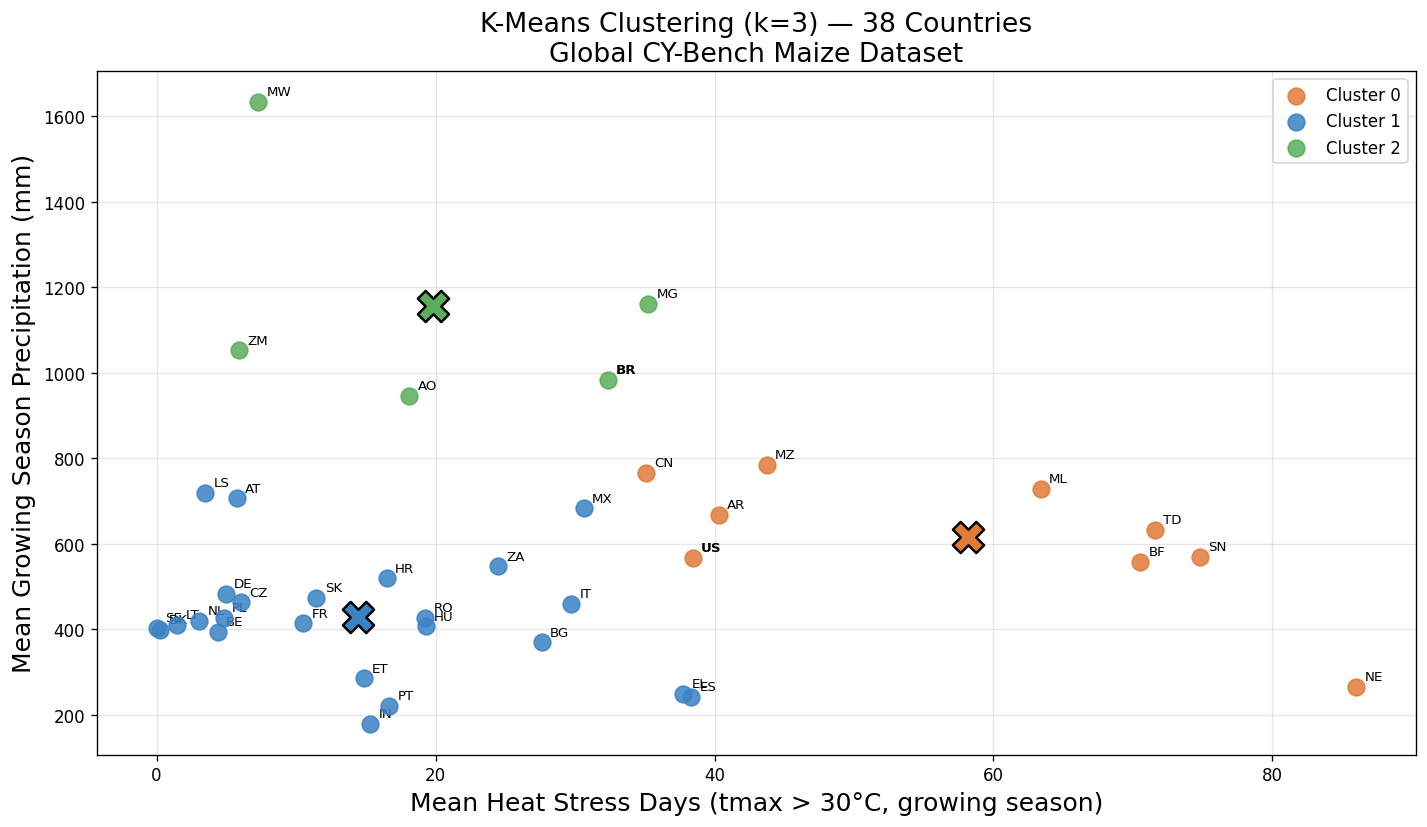

Saved: fig_clustering_global.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

for c in sorted(country_df['cluster'].unique()):
    sub = country_df[country_df['cluster'] == c]
    ax.scatter(sub['heat_stress_days'], sub['prec_gs'],
               c=CLUSTER_COLORS[c], s=100,
               label=f'Cluster {c}', alpha=0.85, zorder=4)
    for _, row in sub.iterrows():
        weight = 'bold' if row['country'] in ['BR', 'US'] else 'normal'
        ax.annotate(row['country'],
                    (row['heat_stress_days'], row['prec_gs']),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=8, fontweight=weight)

# Cluster centers
centers = scaler.inverse_transform(km3.cluster_centers_)
for i, c in enumerate(centers):
    ax.scatter(c[0], c[1], c=CLUSTER_COLORS[i], s=350, marker='X',
               edgecolors='black', linewidths=1.5, zorder=6)

ax.set_xlabel('Mean Heat Stress Days (tmax > 30°C, growing season)', fontsize=15)
ax.set_ylabel('Mean Growing Season Precipitation (mm)', fontsize=15)
ax.set_title('K-Means Clustering (k=3) — 38 Countries\nGlobal CY-Bench Maize Dataset', fontsize=16)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./fig_clustering_global.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_clustering_global.png')

---
## 5. Save Cluster Labels to Global Datasets

In [7]:
country_to_cluster = country_df.set_index('country')['cluster'].to_dict()

# ── Add cluster to ML dataset ─────────────────────────────────────────────────
ml_df['cluster'] = ml_df['country'].map(country_to_cluster)
ml_df.to_csv('./master_global_ml_dataset.csv', index=False)
print(f'Saved: master_global_ml_dataset.csv — cluster column added')
print(f'  Obs per cluster:')
print(ml_df.groupby('cluster').size().to_string())

print()

# ── Add cluster to CV dataset ─────────────────────────────────────────────────
cv_df = pd.read_csv('./cv_global_per_region.csv')
cv_df['cluster'] = cv_df['country'].map(country_to_cluster)
cv_df.to_csv('./cv_global_per_region.csv', index=False)
print(f'Saved: cv_global_per_region.csv — cluster column added')
print(f'  Regions per cluster:')
print(cv_df.groupby('cluster').size().to_string())

print()
print('Cluster label mapping (country → cluster):')
print(country_to_cluster)

Saved: master_global_ml_dataset.csv — cluster column added
  Obs per cluster:
cluster
0    46492
1    20143
2    91259

Saved: cv_global_per_region.csv — cluster column added
  Regions per cluster:
cluster
0    2830
1    1386
2    5580

Cluster label mapping (country → cluster):
{'AO': 2, 'AR': 0, 'AT': 1, 'BE': 1, 'BF': 0, 'BG': 1, 'BR': 2, 'CN': 0, 'CZ': 1, 'DE': 1, 'DK': 1, 'EL': 1, 'ES': 1, 'ET': 1, 'FR': 1, 'HR': 1, 'HU': 1, 'IN': 1, 'IT': 1, 'LS': 1, 'LT': 1, 'MG': 2, 'ML': 0, 'MW': 2, 'MX': 1, 'MZ': 0, 'NE': 0, 'NL': 1, 'PL': 1, 'PT': 1, 'RO': 1, 'SE': 1, 'SK': 1, 'SN': 0, 'TD': 0, 'US': 0, 'ZA': 1, 'ZM': 2}


---
## 6. Kruskal-Wallis Test — Yield Instability by Cluster (RQ1 Preview)

**H₀:** The distribution of maize yield instability (CV of detrended yield) does not differ across the 3 data-driven climate clusters.  
**H₁:** At least one cluster has a significantly different yield instability distribution.  
**Test:** Kruskal-Wallis H-test (non-parametric) | α = 0.05

In [8]:
cluster_ids = sorted(cv_df['cluster'].dropna().unique().astype(int))

print('CV per cluster summary:')
for c in cluster_ids:
    members = sorted(country_df[country_df['cluster'] == c]['country'].tolist())
    sub = cv_df[cv_df['cluster'] == c]['cv'].dropna()
    print(f'  Cluster {c}: {len(sub)} regions | median CV = {sub.median():.1f}% | countries = {members}')

print()

# Kruskal-Wallis test
groups = [cv_df[cv_df['cluster'] == c]['cv'].dropna() for c in cluster_ids]
H_stat, p_value = stats.kruskal(*groups)

print('KRUSKAL-WALLIS H-TEST RESULTS (all 38 countries, by cluster)')
print()
print(f'H statistic : {H_stat:.4f}')
print(f'p-value     : {p_value:.6f}')
print(f'Significance: α = 0.05')
print()
if p_value < 0.05:
    print('Result: REJECT H₀ — yield instability differs significantly across clusters (p < 0.05)')
else:
    print('Result: FAIL TO REJECT H₀ — no significant difference found (p ≥ 0.05)')

CV per cluster summary:
  Cluster 0: 2830 regions | median CV = 17.8% | countries = ['AR', 'BF', 'CN', 'ML', 'MZ', 'NE', 'SN', 'TD', 'US']
  Cluster 1: 1386 regions | median CV = 17.4% | countries = ['AT', 'BE', 'BG', 'CZ', 'DE', 'DK', 'EL', 'ES', 'ET', 'FR', 'HR', 'HU', 'IN', 'IT', 'LS', 'LT', 'MX', 'NL', 'PL', 'PT', 'RO', 'SE', 'SK', 'ZA']
  Cluster 2: 5580 regions | median CV = 24.8% | countries = ['AO', 'BR', 'MG', 'MW', 'ZM']

KRUSKAL-WALLIS H-TEST RESULTS (all 38 countries, by cluster)

H statistic : 1195.2168
p-value     : 0.000000
Significance: α = 0.05

Result: REJECT H₀ — yield instability differs significantly across clusters (p < 0.05)


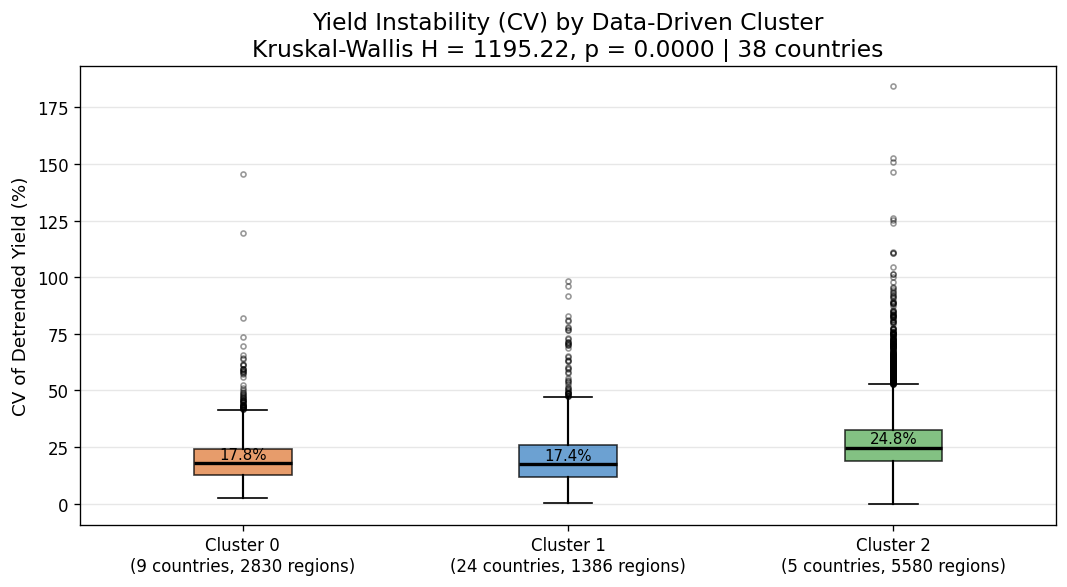

Saved: fig_cv_by_cluster_global.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

cluster_labels_box = []
for c in cluster_ids:
    members = sorted(country_df[country_df['cluster'] == c]['country'].tolist())
    n = len(cv_df[cv_df['cluster'] == c]['cv'].dropna())
    cluster_labels_box.append(f'Cluster {c}\n({len(members)} countries, {n} regions)')

bp = ax.boxplot(
    [cv_df[cv_df['cluster'] == c]['cv'].dropna() for c in cluster_ids],
    tick_labels=cluster_labels_box,
    patch_artist=True,
    medianprops={'color': 'black', 'linewidth': 2},
    whiskerprops={'linewidth': 1.3},
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4}
)
for patch, c in zip(bp['boxes'], cluster_ids):
    patch.set_facecolor(CLUSTER_COLORS[c])
    patch.set_alpha(0.75)

for i, c in enumerate(cluster_ids):
    med = cv_df[cv_df['cluster'] == c]['cv'].median()
    ax.text(i + 1, med + 0.5, f'{med:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('CV of Detrended Yield (%)', fontsize=11)
ax.set_title(f'Yield Instability (CV) by Data-Driven Cluster\n'
             f'Kruskal-Wallis H = {H_stat:.2f}, p = {p_value:.4f} | 38 countries', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./fig_cv_by_cluster_global.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_cv_by_cluster_global.png')

---
## 7. Summary

| Step | Result |
|---|---|
| Countries clustered | 38 (from global pipeline) |
| Features used | `heat_stress_days`, `prec_gs` (hemisphere-adjusted) |
| k chosen | 3 (data-driven, confirmed by elbow + silhouette) |
| KW test | See output above |
| Outputs saved | `master_global_ml_dataset.csv` + `cv_global_per_region.csv` (both with `cluster` column) |

**Next steps:**
- `step5_feature_selection.ipynb` — re-run VIF/correlation on global ML dataset
- `step6_models.ipynb` — ML models trained on global dataset, evaluated per cluster

---

---
## 6. Summary

**Key questions answered:**
- Where do our 9 European countries fall in the global cluster structure?
- Do the data-driven clusters agree with the theoretical Köppen-based panels?
- Which countries, if any, cluster differently than expected?

**Next step:** Use these findings to enrich the RQ1 discussion — if clusters agree with panels, the theoretical grouping is data-validated. If not, discuss which countries are climatically ambiguous and why.

---